In [198]:
#  explore null ,encode,scale
#  pca on all data
#  all data without pca (pca in visualize)
#  top  feature vairance (pca in visualize)
#  top  feature vairance  with pca 
# all combinations and get best 2 and k


In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score, roc_curve,ConfusionMatrixDisplay,silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans , DBSCAN
from itertools import combinations
from sklearn.decomposition import PCA

In [200]:
df = pd.read_csv('sales_data_sample.csv', encoding="latin1")

In [201]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,05/07/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,07/01/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [203]:
df.shape

(2823, 25)

In [204]:
num=df.select_dtypes(exclude='object')
cat=df.select_dtypes(include='object')

In [205]:
cat.describe()

,ORDERDATE,STATUS,PRODUCTLINE,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
count,2823,2823,2823,2823,2823,2823,2823,302,2823,1337,2747,2823,1749,2823,2823,2823
unique,252,6,7,109,92,91,92,9,73,16,73,19,3,77,72,3
top,11/14/2003 0:00,Shipped,Classic Cars,S18_3232,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Level 3,Madrid,CA,28034,USA,EMEA,Freyre,Diego,Medium
freq,38,2617,967,52,259,259,259,55,304,416,259,1004,1407,259,259,1384


In [206]:
num.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [207]:
df.isnull().sum().sort_values(ascending=False)

ADDRESSLINE2        2521
STATE               1486
TERRITORY           1074
POSTALCODE            76
SALES                  0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
ORDERNUMBER            0
MONTH_ID               0
QTR_ID                 0
STATUS                 0
ORDERDATE              0
PRODUCTCODE            0
YEAR_ID                0
MSRP                   0
PRODUCTLINE            0
ADDRESSLINE1           0
PHONE                  0
CUSTOMERNAME           0
CITY                   0
COUNTRY                0
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [208]:
df.drop(columns=['ADDRESSLINE2'],inplace=True)

In [209]:
df.shape

(2823, 24)

In [210]:
for col in df.columns:
 if df[col].isnull().sum()>1:
    if df[col].dtype=='object':
            df[col].fillna(df[col].mode()[0],inplace=True)
    else:
            df[col].fillna(df[col].mean(),inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_17744\3560808703.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [211]:
df.isnull().sum().sort_values(ascending=False)

ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64

In [212]:
label =LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=label.fit_transform(df[col])

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   int64  
 6   STATUS            2823 non-null   int64  
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   int64  
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   int64  
 13  CUSTOMERNAME      2823 non-null   int64  
 14  PHONE             2823 non-null   int64  
 15  ADDRESSLINE1      2823 non-null   int64  
 16  CITY              2823 non-null   int64  


In [214]:
# plt.figure(figsize=(20,18))
# sns.boxenplot(df)
# plt.xticks(rotation=90)
# plt.show()

In [215]:
from sklearn.preprocessing import RobustScaler
scale=RobustScaler()
df_scaled=scale.fit_transform(df)
df=pd.DataFrame(df_scaled,columns=df.columns)

In [216]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42) 
yhat = iso.fit_predict(df)
mask = yhat != -1
df_no_outliers = df[mask]

print("besfore:", df.shape)
print("after:", df_no_outliers.shape)


besfore: (2823, 24)
after: (2681, 24)


In [217]:
df2=df
df3=df
pca=PCA(n_components=2)
X=pca.fit_transform(df)
X=pd.DataFrame(X,columns=['c1','c2'])

In [218]:
X

,c1,c2
0,1.975279,-0.195739
1,-0.633486,-0.247808
2,-0.578314,0.699464
3,-0.707754,0.528717
4,-0.473466,1.114882
...,...,...
2818,-0.686577,-1.241980
2819,-0.986038,-0.064457
2820,-0.901450,0.440277
2821,-0.484060,-1.421595


In [219]:
score=[]
elbow=[]
best_score=-1
best_k=-1
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42)
    y_pred=model.fit_predict(X)
    tmp=(silhouette_score(X,y_pred))
    score.append(tmp)
    elbow.append(model.inertia_)
    if tmp>best_score:
     best_score=tmp
     best_k=k

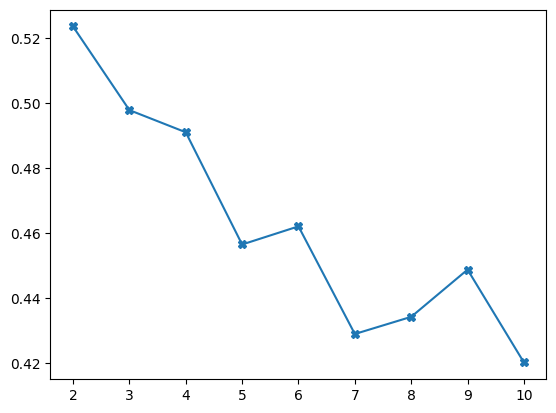

In [220]:
plt.plot(range(2,11),score,marker="X")
plt.show()

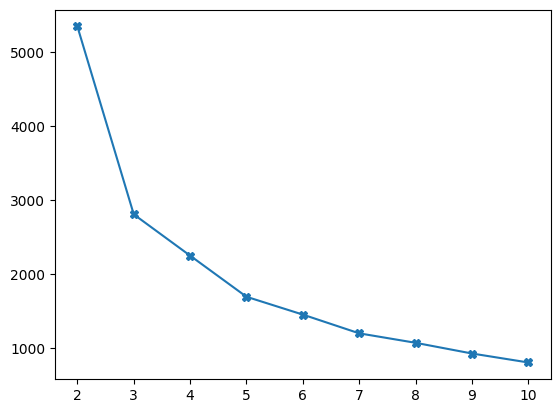

In [221]:
plt.plot(range(2,11),elbow,marker="X")
plt.show()

In [222]:
best_score

np.float64(0.5236404743484243)

In [223]:
best_k

2

In [224]:
km=KMeans(n_clusters=2,random_state=42)
km.fit(X)

KMeans(n_clusters=2, random_state=42)

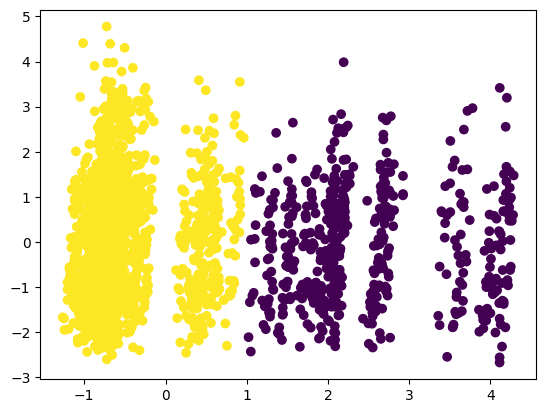

In [225]:
plt.scatter(X['c1'],X['c2'],c=km.labels_)
plt.show()

In [226]:
#try all data without pca
score=[]
elbow=[]
best_score=-1
best_k=-1
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42)
    y_pred=model.fit_predict(df2)
    tmp=(silhouette_score(df2,y_pred))
    score.append(tmp)
    elbow.append(model.inertia_)
    if tmp>best_score:
     best_score=tmp
     best_k=k

In [227]:
best_score

np.float64(0.1965686416531009)

In [228]:
best_k

2

In [229]:
km=KMeans(n_clusters=2,random_state=42)
km.fit(df2)

KMeans(n_clusters=2, random_state=42)

In [230]:
df2pca=PCA(n_components=2)
Z=df2pca.fit_transform(df2)
Z=pd.DataFrame(Z,columns=['c1','c2'])

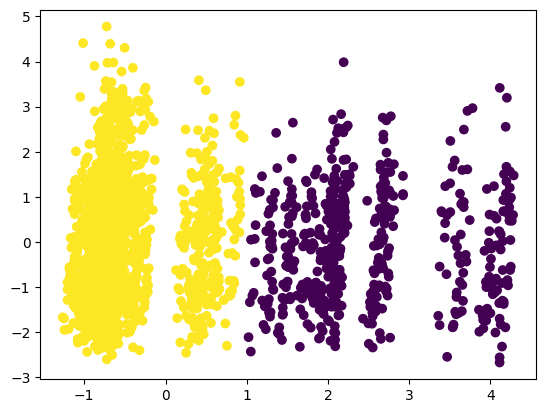

In [231]:
plt.scatter(Z['c1'],Z['c2'],c=km.labels_)
plt.show()

In [232]:
#try variance
variance=df3.var().sort_values(ascending=False)
variance
top_features = variance.head(10).index
print(top_features)
df4 = df3[top_features]
variance

Index(['STATE', 'STATUS', 'SALES', 'MSRP', 'ORDERLINENUMBER', 'YEAR_ID',
       'CONTACTLASTNAME', 'ORDERDATE', 'CUSTOMERNAME', 'ADDRESSLINE1'],
      dtype='object')


STATE               1.628529
STATUS              0.773372
SALES               0.638757
MSRP                0.515009
ORDERLINENUMBER     0.496048
YEAR_ID             0.489538
CONTACTLASTNAME     0.481504
ORDERDATE           0.464174
CUSTOMERNAME        0.430617
ADDRESSLINE1        0.422772
PRICEEACH           0.419719
CITY                0.406503
QUANTITYORDERED     0.370686
QTR_ID              0.362331
ORDERNUMBER         0.359886
DEALSIZE            0.351054
PHONE               0.350628
PRODUCTCODE         0.342123
POSTALCODE          0.282326
MONTH_ID            0.272877
COUNTRY             0.264348
CONTACTFIRSTNAME    0.262805
PRODUCTLINE         0.232645
TERRITORY           0.119935
dtype: float64

In [233]:
score=[]
elbow=[]
best_score=-1
best_k=-1
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42)
    y_pred=model.fit_predict(df3[['STATE','STATUS','SALES','MSRP']])
    tmp=(silhouette_score(df3[['STATE','STATUS','SALES','MSRP']],y_pred))
    score.append(tmp)
    elbow.append(model.inertia_)
    if tmp>best_score:
     best_score=tmp
     best_k=k

In [234]:
best_score

np.float64(0.5111627189797958)

In [235]:
best_k

2

In [236]:
mod=KMeans(n_clusters=2,random_state=42)
mod.fit(df3[['STATE','STATUS','SALES','MSRP']])

KMeans(n_clusters=2, random_state=42)

In [237]:
pc=PCA(n_components=2)
C=pc.fit_transform(df3)
C=pd.DataFrame(C,columns=['C1',"C2"])

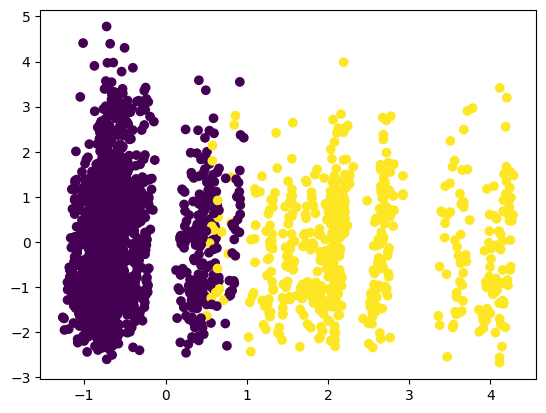

In [238]:
plt.scatter(C['C1'],C['C2'],c=mod.labels_)
plt.show()

In [ ]:
#tryss combinations
from itertools import combinations
pair=list(combinations(df4.columns,2))
pair

[('STATE', 'STATUS'),
 ('STATE', 'SALES'),
 ('STATE', 'MSRP'),
 ('STATE', 'ORDERLINENUMBER'),
 ('STATE', 'YEAR_ID'),
 ('STATE', 'CONTACTLASTNAME'),
 ('STATE', 'ORDERDATE'),
 ('STATE', 'CUSTOMERNAME'),
 ('STATE', 'ADDRESSLINE1'),
 ('STATUS', 'SALES'),
 ('STATUS', 'MSRP'),
 ('STATUS', 'ORDERLINENUMBER'),
 ('STATUS', 'YEAR_ID'),
 ('STATUS', 'CONTACTLASTNAME'),
 ('STATUS', 'ORDERDATE'),
 ('STATUS', 'CUSTOMERNAME'),
 ('STATUS', 'ADDRESSLINE1'),
 ('SALES', 'MSRP'),
 ('SALES', 'ORDERLINENUMBER'),
 ('SALES', 'YEAR_ID'),
 ('SALES', 'CONTACTLASTNAME'),
 ('SALES', 'ORDERDATE'),
 ('SALES', 'CUSTOMERNAME'),
 ('SALES', 'ADDRESSLINE1'),
 ('MSRP', 'ORDERLINENUMBER'),
 ('MSRP', 'YEAR_ID'),
 ('MSRP', 'CONTACTLASTNAME'),
 ('MSRP', 'ORDERDATE'),
 ('MSRP', 'CUSTOMERNAME'),
 ('MSRP', 'ADDRESSLINE1'),
 ('ORDERLINENUMBER', 'YEAR_ID'),
 ('ORDERLINENUMBER', 'CONTACTLASTNAME'),
 ('ORDERLINENUMBER', 'ORDERDATE'),
 ('ORDERLINENUMBER', 'CUSTOMERNAME'),
 ('ORDERLINENUMBER', 'ADDRESSLINE1'),
 ('YEAR_ID', 'CONTACTLAST

In [240]:
c1=""
c2=""
for f1,f2 in pair:
    best_score=-1
    best_k=None
    for k in range(2,11):
        mod = KMeans(n_clusters=k,random_state=42)
        label = mod.fit_predict(df4[[f1,f2]])
        score=silhouette_score(df4[[f1,f2]],label)
        if score > best_score:
            best_score=score
            best_k=k
            c1=f1
            c2=f2

In [241]:
c1,c2

('CUSTOMERNAME', 'ADDRESSLINE1')

In [242]:
best_score,best_k

(np.float64(0.5487024038927328), 10)

In [243]:
km=KMeans(n_clusters=10,random_state=42)
km.fit(df4)

KMeans(n_clusters=10, random_state=42)

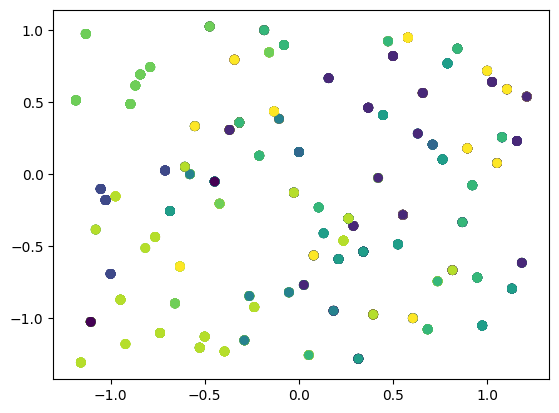

In [244]:
plt.scatter(df4['CUSTOMERNAME'],df4['ADDRESSLINE1'],c=km.labels_)
plt.show()